# ALGORITMI LABEL SETTING PER IL PRBLEMA DEL CAMMINO MINIMO

#### Gli algoritmi label setting ad ogni iterazione rendono permanente (ottima) un’etichetta. Essi sono applicabili quando:

#### a) il grafo è aciclico

#### b) il grafo non presenta archi di costo negativo

## Ordinamento topologico di un grafo

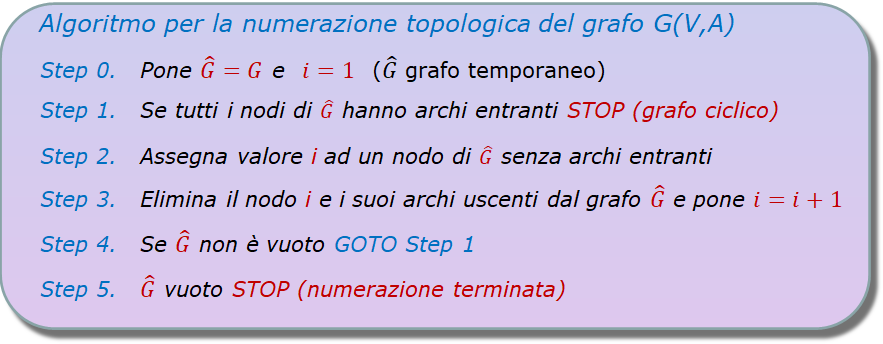

### Dati di input: 

- G $\rightarrow$ grafo da ordinare 

### Output: 

- isCyclic $\rightarrow$ TRUE se il grafo è ciclico
- orderedlist $\rightarrow$ lista in cui nella posizione $i-esima$ c'è il nodo con numero d'ordine $i$

In [9]:
def TopologicalSort(G) :
    # dizionario chiave: numero d'ordine, valore: nodo
    orderedList = [i for i in range(len(G.nodes))]  

    # Crea una copia del file G
    G_Temp = nx.DiGraph()
    # aggiunge a G_Temp tutti i nodi di G
    G_Temp.add_nodes_from(G.nodes)
    # aggiunge a G_Temp tutti gli archi di G
    G_Temp.add_edges_from(G.edges)

    stop = False
    currentNum = 0
    while stop == False :

        # Lista di nodi senza archi entranti
        toRemove = [i for i in G_Temp.nodes if G_Temp.in_degree(i) == 0]
    
        if len(toRemove) == 0 :
            stop = True
            isCyclic = True
        else :
            # aggiunge a orderedList i nodi senza archi entranti con il relativo numero d'ordine
            for i in toRemove :
               orderedList[currentNum] = i
               currentNum += 1
                          
            # elimina da G_Temp il nodo senza archi entranti 
            G_Temp.remove_nodes_from(toRemove)
        
            if len(G_Temp.nodes) == 0 :
                stop = True 
                isCyclic = False
                
    return isCyclic, orderedList

### Calcola l'arborescenza dei cammini minimi su un grafo aciclico

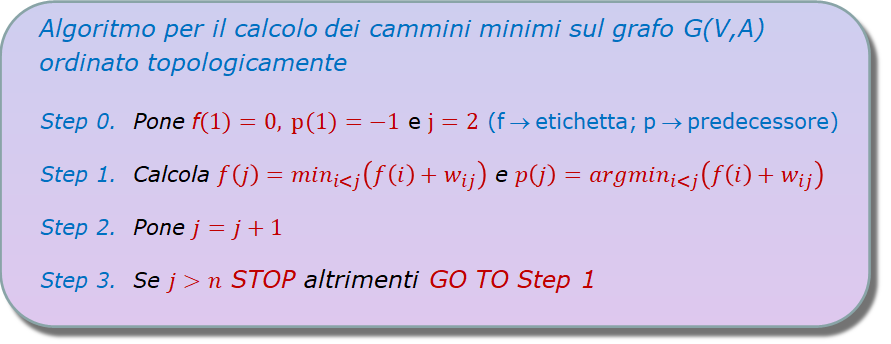

### Dati di input: 

- G $\rightarrow$ grafo da ordinare 
- orderedList $\rightarrow$ lista ordinamento topologico

### Output: 

- label $\rightarrow$ dict con chiave: *nodo*, valore: (etichetta, predecessore)

In [25]:
import numpy as np

def ShortestPathOnAcyclicGraph(G, orderedList):

    # chiave: nodo, valore: (etic, pred)
    label = {i: (np.inf, -1) for i in G.nodes}
    label[orderedList[0]] = (0,-1)

    # edge_labels ha chiave (i,j), peso (c_{ij})
    edge_labels = nx.get_edge_attributes(G, "weight")

    for j in range(1, len(orderedList)) :
        for i in range(j) :
            if (orderedList[i],orderedList[j]) in G.edges :
                if label[orderedList[i]][0] + edge_labels[(orderedList[i],orderedList[j])] < label[orderedList[j]][0] :
                    label[orderedList[j]] = (label[orderedList[i]][0] + edge_labels[(orderedList[i],orderedList[j])], 
                                             orderedList[i])
    return label

### Algoritmo di Dijkstra

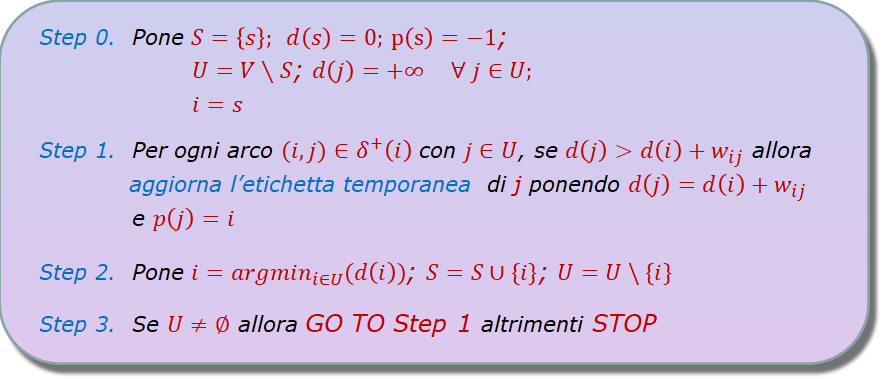

### Dati di input: 

- G $\rightarrow$ grafo da ordinare 
- ori $\rightarrow$ nodo origine

### Output: 

- label $\rightarrow$ dict con chiave: *nodo*, valore: (etichetta, predecessore)

In [2]:
def ShortestPathDijkstra(G, ori):

    # edge_labels ha chiave (i,j), peso (c_{ij})
    edge_labels = nx.get_edge_attributes(G, "weight")

    # chiave: nodo, valore: (etic, pred)
    label = {i: (np.inf, -1) for i in G.nodes}
    label[ori] = (0, -1)
    
    # inizializzazioni
    S = [ori]
    U = [u for u in G.nodes if u != ori]
    currentNode = ori

    while len(U) != 0 :
    
        # aggiorna le etichette temporanee
        for e in G.out_edges(currentNode):
            if e[1] in U and (label[currentNode][0] + edge_labels[(currentNode,e[1])] < label[e[1]][0]) :
                label[e[1]] = (label[currentNode][0] + edge_labels[(currentNode,e[1])], currentNode) 

        # cerca l'etichetta temporanea più piccola
        minEtic = np.inf
        argMinEtic = -1
        for i in U :
            if label[i][0] < minEtic :
                minEtic = label[i][0]
                argMinEtic = i
    
        # rende definitiva l'etichetta di argMinEtic
        currentNode = argMinEtic
        S.append(argMinEtic)
        U.remove(argMinEtic)

    return label

### Legge il grafo input dal file *shortest_path_example_pos.dat* 

In [28]:
with open("data/shortest_path_example_pos.dat", "r") as file:
    lines = file.readlines()
    
numNodes = int(lines[0].strip("\n").split(" ")[2])
ori = int(lines[1].strip("\n").split(" ")[2])
dest = int(lines[2].strip("\n").split(" ")[2])

Nodi = []
PosOfNodes = {}
# legge i nodi per posizione
for k in range(numNodes):
    row = lines[4+k].strip("\n").split(" ")
    Nodi.append(int(row[0]))
    PosOfNodes[int(row[0])] = (float(row[1]), float(row[2]))

#Archi = {}
Archi = []
for k in range(5+numNodes, len(lines)) :
    row = lines[k].strip("\n").split(" ")
    #Archi[(int(row[0]), int(row[1]))] = float(row[2])
    Archi.append((int(row[0]), int(row[1]), float(row[2])))

### Crea il grafo e lo disegna

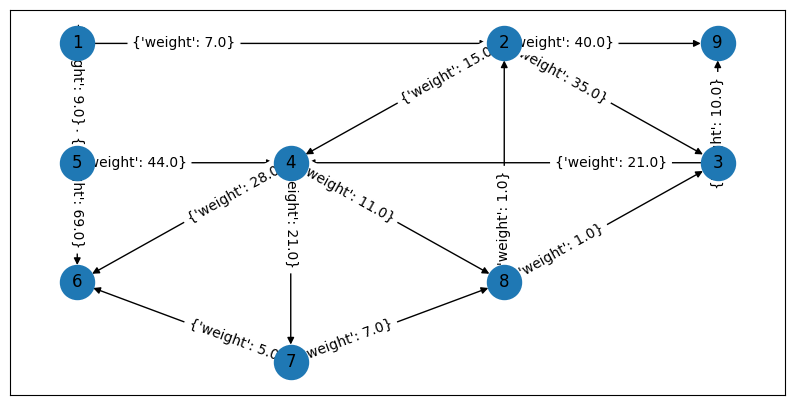

In [29]:
import networkx as nx 
import matplotlib.pyplot as plt

G = nx.DiGraph()

# aggiunge i nodi
G.add_nodes_from(Nodi)

# aggiunge gli archi
G.add_weighted_edges_from(Archi)

plt.figure(figsize=(10,5))
nx.draw_networkx(G, PosOfNodes, with_labels=True, node_size=600)
#nx.draw_networkx_edge_labels(G,PosOfNodes, edge_labels=Archi, label_pos=0.75)
nx.draw_networkx_edge_labels(G, PosOfNodes, label_pos=0.75)
plt.draw()

### Effettua l'ordinamento topologico di G  

In [30]:
isCyclic, orderedList = TopologicalSort(G) 
print(isCyclic)

True


### Se il grafo è aciclico lo risolve con l'algoritmo di Dantzig

In [27]:
if isCyclic == False :
    label = ShortestPathOnAcyclicGraph(G, orderedList)
print(label)

{1: (0, -1), 2: (7.0, 1), 3: (inf, -1), 4: (53.0, 5), 5: (9.0, 1), 6: (78.0, 5), 7: (74.0, 4), 8: (64.0, 4), 9: (47.0, 2)}


### Se il grafo è ciclico lo risolve con l'algoritmo di Dijkstra

In [36]:
if isCyclic == True :
    ori = 1
    label = ShortestPathDijkstra(G, ori)
print(label)

{1: (0, -1), 2: (7.0, 1), 3: (34.0, 8), 4: (22.0, 2), 5: (9.0, 1), 6: (48.0, 7), 7: (43.0, 4), 8: (33.0, 4), 9: (44.0, 3)}


### Colora di rosso l'arborescenza dei cammini minimi

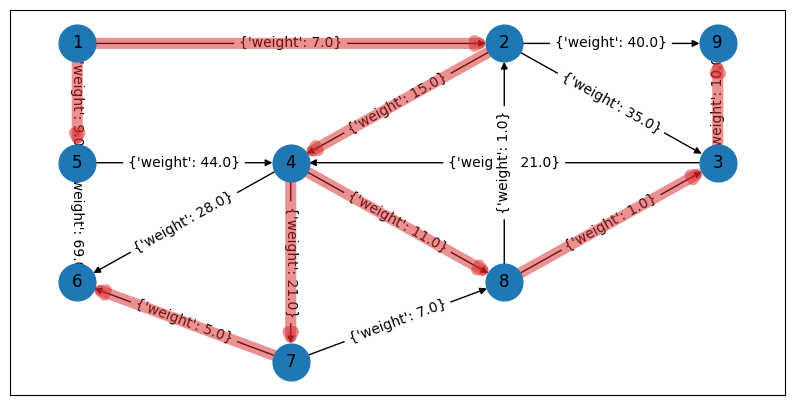

In [35]:
# SOL è la lista di archi della soluzione
SOL = []
for i in G.nodes :
    if label[i][1] > -1 :
        SOL.append((label[i][1],i))
    
plt.figure(figsize=(10,5))
nx.draw_networkx(G, PosOfNodes, with_labels=True, node_size=700)
nx.draw_networkx_edge_labels(G, PosOfNodes, label_pos=0.5)
# archi della soluzione
nx.draw_networkx_edges(G, PosOfNodes, edgelist=SOL, width=8, alpha=0.5, edge_color="tab:red")
plt.draw()       